In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

import pandas as pd

from epbl_basic import calculate_M

import torch

In [2]:
def calculate_rolling_average(
        data: np.ndarray,
        window_size: int = 10
) -> np.ndarray:
    return np.convolve(np.pad(data, pad_width=int(window_size/2), mode="reflect"), np.ones(window_size)/window_size, mode='valid')[:-1]

In [3]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [4]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [12]:
mean_vals = False

data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_expanded_2283_corrected'

if mean_vals:
    bl_data = np.load(os.path.join(data_directory, f'{dataset_name}_mean_bls.npy'))
    M_data = np.load(os.path.join(data_directory, f'{dataset_name}_mean_Ms.npy'))

else:
    bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_bl.nc'))
    bl_tke_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_tke_bl.nc'))
    M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
    u_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_surf.nc'))
    v_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_surf.nc'))
    u_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_u_bl.nc'))
    v_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_v_bl.nc'))
    SS_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_SS_bl_avg.nc'))
    NN_bl_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_NN_bl_avg.nc'))
    wb_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_wb_dataset.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [13]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
coriolis_freqs = np.array([calculate_f(case['lat']) for case in gotm_case_dict.values()])
u_stars = np.array([(case['tx'] / rho0) ** 0.5 for case in gotm_case_dict.values()])
taus = np.array([case['tx'] for case in gotm_case_dict.values()])

Bs = g * alpha * heat_fluxes / (rho0 * cp)

if mean_vals:

    bls = bl_data
    Ms = M_data

else:

    n_cases, t_timesteps = bl_data.bl.values[:,2:-1].shape

    bls_smoothed = np.empty((n_cases, t_timesteps))
    bls_im1_smoothed = np.empty((n_cases, t_timesteps))
    for i in range(n_cases):
        bls_smoothed[i] = calculate_rolling_average(bl_data.bl.values[i,2:-1])
        bls_im1_smoothed[i] = np.pad(bls_smoothed[i,:-1], pad_width=(1,0), mode="edge")

    bls = bl_data.bl[:,2:-1].values.flatten()
    bls_im1 = bl_data.bl[:,2:-2].pad(time=(1,0), mode="constant", constant_values=1).values.flatten()
    bls_smoothed = bls_smoothed.flatten()
    bls_im1_smoothed = bls_im1_smoothed.flatten()
    Ms = M_data.M.values[:,2:-1].flatten()
    Ms_im1 = M_data.M.values[:,1:-2].flatten()
    dMs = (M_data.M[:,1:].values - M_data.M[:,:-1].values)[:,2:].flatten()
    tke_bls = -bl_tke_data.bl.values[:,2:-1].flatten()
    us = u_data.u_surf.values[:,2:-1].flatten()
    vs = v_data.v_surf.values[:,2:-1].flatten()
    us_bl = u_bl_data.u_bl.values[:,2:-1].flatten()
    vs_bl = v_bl_data.v_bl.values[:,2:-1].flatten()
    SS_bl = SS_bl_data.SS_bl_mean.values[:,2:-1].flatten()
    NN_bl = NN_bl_data.NN_bl_mean.values[:,2:-1].flatten()
    wbs = wb_data.wb.values[:,2:-1].flatten()

    coriolis_freqs = np.repeat(coriolis_freqs, t_timesteps)
    u_stars = np.repeat(u_stars, t_timesteps)
    taus = np.repeat(taus, t_timesteps)
    Bs = np.repeat(Bs, t_timesteps)

    surface_magnitudes = taus*np.sqrt(us**2+vs**2)
    surface_angles = np.arccos(us*taus/(np.sqrt(us**2+vs**2)*taus))
    surface_ekin_input = abs(surface_magnitudes*np.cos(surface_angles))

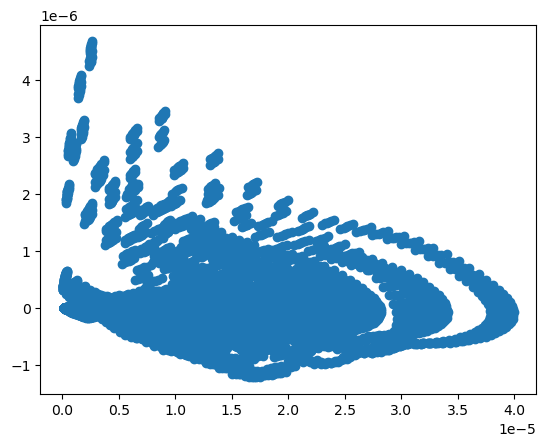

In [109]:
plt.scatter(Ms_im1, dMs)

In [14]:
ePBL_Ms = calculate_M(
    H=tke_bls,
    f=coriolis_freqs,
    u_star=u_stars,
    B=Bs,
    wb=-wbs,
    neutral_mode="Nb"
)

In [15]:
ePBL_Ms_im1 = calculate_M(
    H=-bl_tke_data.bl.values[:,1:-2].flatten(),
    f=coriolis_freqs,
    u_star=u_stars,
    B=Bs,
    wb=-wb_data.wb.values[:,1:-2].flatten(),
    neutral_mode="Nb"
)

In [16]:
Ms_over_ePBL_Ms = Ms/ePBL_Ms
dMs_over_ePBL_Ms = dMs/ePBL_Ms
Ms_im1_over_ePBL_Ms_im1 = Ms_im1/ePBL_Ms_im1
f_H_over_u_star = coriolis_freqs*tke_bls/u_stars
ff_over_NN = coriolis_freqs**2/NN_bl
NN_over_SS = NN_bl/SS_bl
surf_mag_over_u_star_squared = surface_magnitudes/u_stars**2
B_over_u_star_squared_f = surface_magnitudes/(u_stars**2*coriolis_freqs)

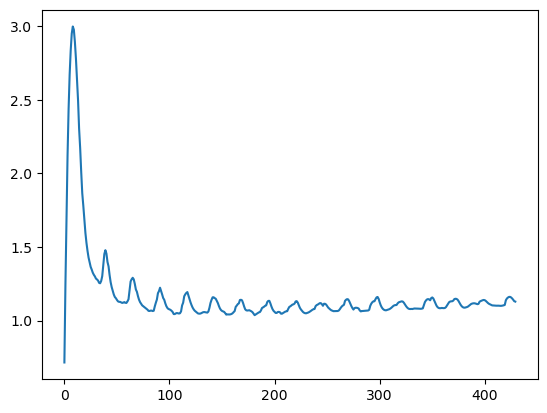

In [32]:
i=2000
plt.plot(Ms_over_ePBL_Ms[i*430:(i+1)*430])

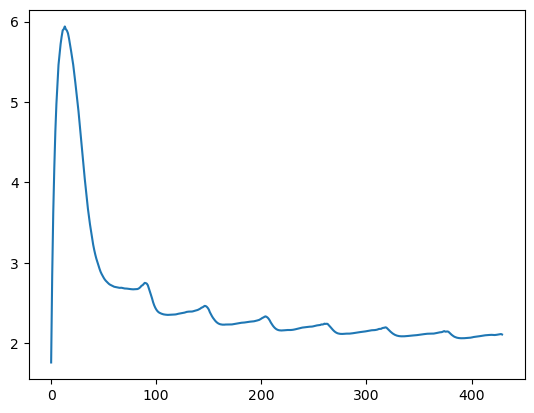

In [86]:
i=10
plt.plot((Ms/ePBL_Ms)[i*430:(i+1)*430])

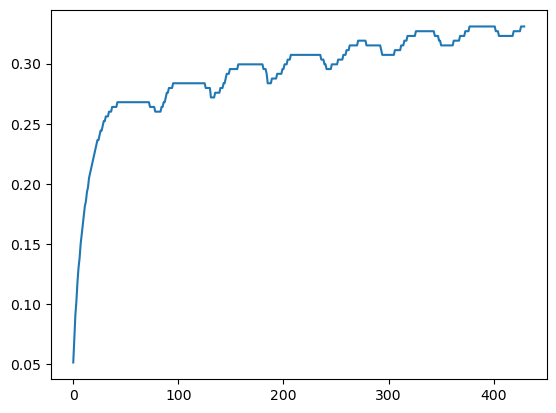

In [87]:
i=10
plt.plot((bls*coriolis_freqs/u_stars)[i*430:(i+1)*430])

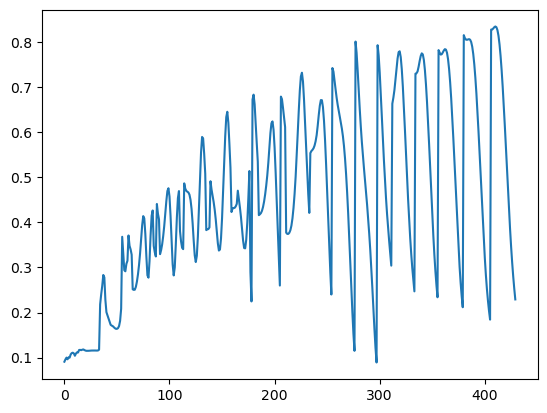

In [88]:
i=20
plt.plot((NN_bl/coriolis_freqs)[i*430:(i+1)*430])

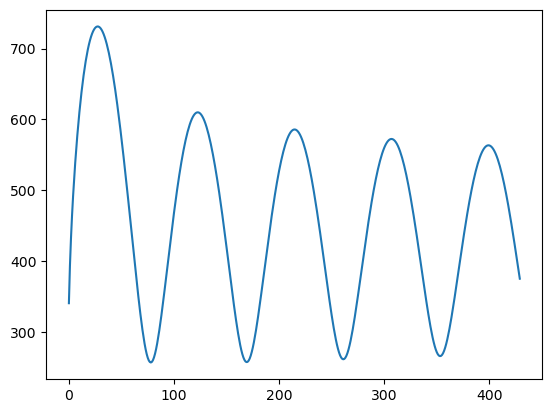

In [89]:
i=100
plt.plot((surface_magnitudes/(u_stars**2))[i*430:(i+1)*430])

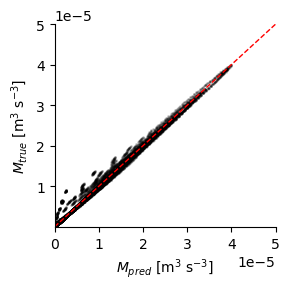

In [20]:
xs, ys = np.linspace(0., 5e-5, 1000), np.linspace(0., 5e-5, 1000)

fig, ax = plt.subplots(1,1,figsize=(3,3))
ax.scatter(Ms_im1, Ms, color="black", s=1, alpha=.2,)
ax.plot(xs, ys, color="red", linestyle="dashed", linewidth=1)
ax.set_yticks([1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xticks([0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])
ax.set_xlim(0, 5e-5)
ax.set_ylim(0, 5e-5)
ax.set_ylabel("$M_{true}$ [m$^3$ s$^{-3}$]")
ax.set_xlabel("$M_{pred}$ [m$^3$ s$^{-3}$]")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig("persistence_mtrue_mpred.png", dpi=300)

In [7]:
t_timesteps

431

(array([155160., 155160., 155160., 155160.,      0., 155160., 155160.,
        155160., 155160., 155160.]),
 array([-4.77604674e-08, -3.82083739e-08, -2.86562804e-08, -1.91041870e-08,
        -9.55209348e-09,  0.00000000e+00,  9.55209348e-09,  1.91041870e-08,
         2.86562804e-08,  3.82083739e-08,  4.77604674e-08]),
 <BarContainer object of 10 artists>)

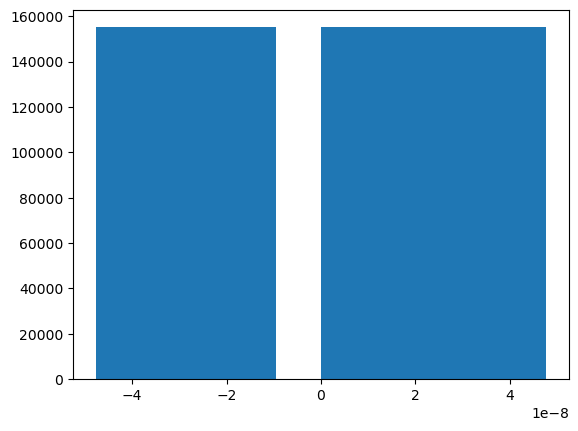

In [26]:
plt.hist(Bs)

(array([  225.,  3021.,  7368.,  8971., 12048., 18266., 19029., 15205.,
         7883.,  1080.]),
 array([-5.14749609, -4.92529127, -4.70308646, -4.48088165, -4.25867684,
        -4.03647203, -3.81426722, -3.59206241, -3.3698576 , -3.14765279,
        -2.92544798]),
 <BarContainer object of 10 artists>)

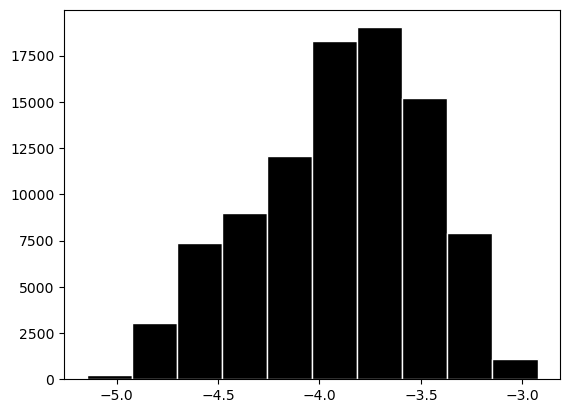

In [9]:
plt.hist(np.log10(NN_bl), color="black", ec="white")

(array([  3555.,  25971., 171490., 390709., 406418., 215835., 115521.,
         46196.,  16541.,   4204.]),
 array([ 1.        ,  2.87484177,  4.74968353,  6.6245253 ,  8.49936706,
        10.37420883, 12.24905059, 14.12389236, 15.99873413, 17.87357589,
        19.74841766]),
 <BarContainer object of 10 artists>)

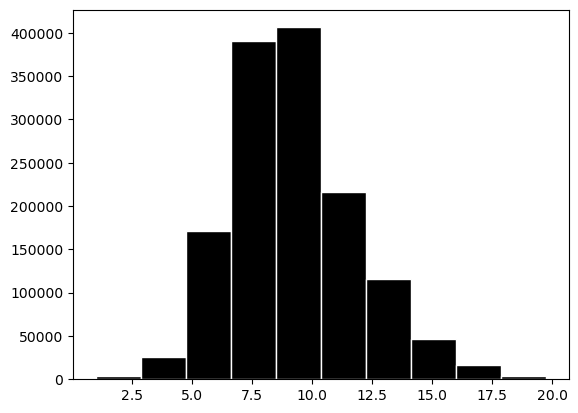

In [31]:
plt.hist(np.sqrt(bls_im1), color="black", ec="white")

(array([ 36879.,  86747.,  42910., 108184., 140572., 187794., 273914.,
        359982., 149140.,  10318.]),
 array([-2.28229657, -2.04875893, -1.81522128, -1.58168364, -1.348146  ,
        -1.11460835, -0.88107071, -0.64753306, -0.41399542, -0.18045778,
         0.05307987]),
 <BarContainer object of 10 artists>)

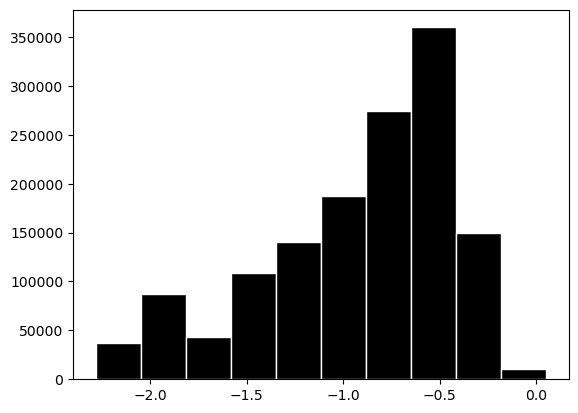

In [32]:
plt.hist(np.log10(surface_magnitudes), color="black", ec="white")

(array([2.00000e+00, 5.00000e+00, 2.50000e+01, 7.40000e+01, 4.87000e+02,
        2.35620e+04, 1.50777e+05, 2.96441e+05, 6.27123e+05, 2.97944e+05]),
 array([-5.53261129, -4.98149942, -4.43038755, -3.87927567, -3.3281638 ,
        -2.77705193, -2.22594006, -1.67482819, -1.12371632, -0.57260444,
        -0.02149257]),
 <BarContainer object of 10 artists>)

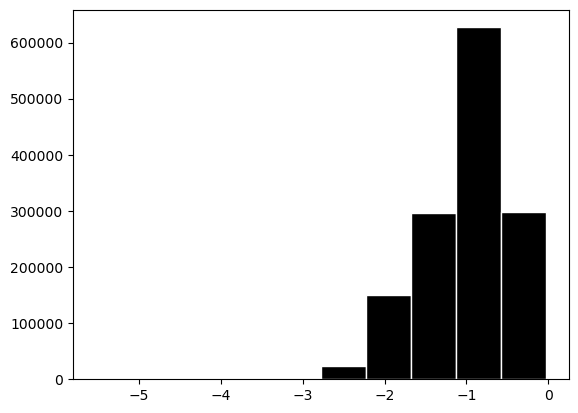

In [33]:
plt.hist(np.log10(surface_ekin_input), color="black", ec="white")

(array([2.50000e+01, 3.49000e+02, 1.89700e+03, 5.80200e+03, 2.05180e+04,
        1.39875e+05, 4.34885e+05, 2.78917e+05, 3.86605e+05, 1.27567e+05]),
 array([-10.05546722,  -9.29047874,  -8.52549027,  -7.76050179,
         -6.99551332,  -6.23052485,  -5.46553637,  -4.7005479 ,
         -3.93555943,  -3.17057095,  -2.40558248]),
 <BarContainer object of 10 artists>)

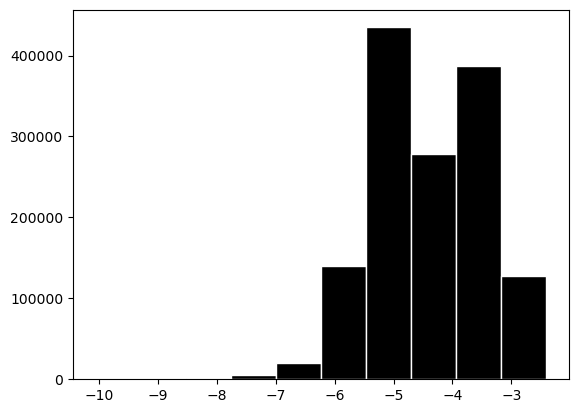

In [34]:
plt.hist(np.log10(SS_bl), color="black", ec="white")

(array([  1896.,   5806.,  60743., 238659., 349855., 385429., 238636.,
         83749.,  27604.,   4063.]),
 array([0.14990901, 0.26245902, 0.37500903, 0.48755903, 0.60010904,
        0.71265905, 0.82520905, 0.93775906, 1.05030907, 1.16285907,
        1.27540908]),
 <BarContainer object of 10 artists>)

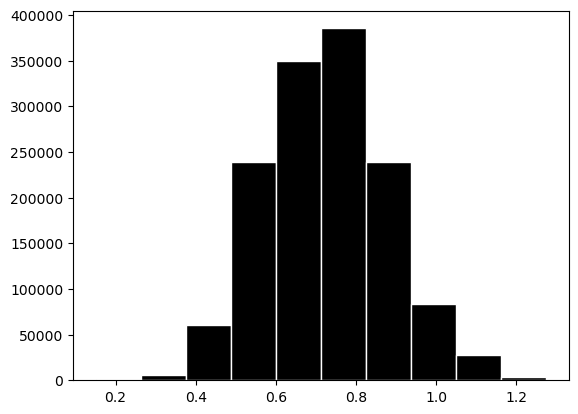

In [35]:
plt.hist(np.sqrt(surface_angles), color="black", ec="white")

In [36]:
# transformations
sqrt_bls = np.sqrt(bls)
sqrt_bls_im1 = np.sqrt(bls_im1)
log_NN_bl = np.log10(NN_bl)
log_SS_bl = np.log10(SS_bl)
sqrt_surface_angles = np.sqrt(surface_angles)
log_surface_ekin_input = np.log10(surface_ekin_input)
log_surface_magnitudes = np.log10(surface_magnitudes)

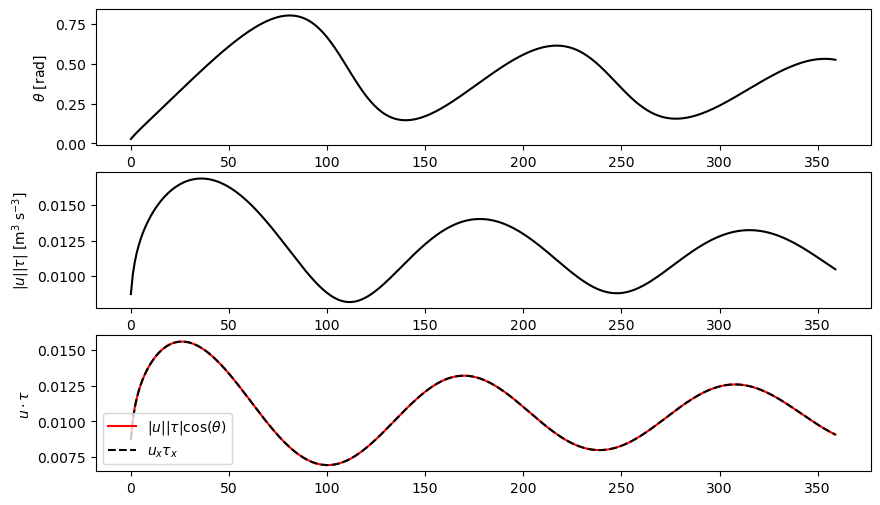

In [21]:
fig, ax = plt.subplots(3,1,figsize=(10,6))

ax[0].set_ylabel(r"$\theta$ [rad]")
ax[0].plot(surface_angles[0:360], color="black")
ax[1].set_ylabel(r"$|u||\tau|$ [m$^3$ s$^{-3}$]")
ax[1].plot(surface_magnitudes[0:360], color="black")
ax[2].set_ylabel(r"$u \cdot \tau$")
ax[2].plot(surface_ekin_input[0:360], color="red", label=r"$|u||\tau|\cos(\theta)$")
ax[2].plot(us[0:360]*taus[0:360], color="black", linestyle="dashed", label=r"$u_x\tau_x$")
ax[2].legend()

In [86]:
torch_dataset_name = f"{dataset_name}_mean_dataset_M_target_bl_smoothed.pt" if mean_vals else f"{dataset_name}_dataset_M_target_bl_smoothed.pt"
# dataset = torch.tensor(np.array([
#     coriolis_freqs, u_stars, sqrt_bls, Bs, log_surface_magnitudes, sqrt_surface_angles, log_surface_ekin_input, sqrt_bls_im1,
#     us_bl, vs_bl, log_SS_bl, log_NN_bl, 
#     Ms
# ]))
dataset = torch.tensor(np.array([
    coriolis_freqs, u_stars, bls_smoothed, Bs, surface_magnitudes, surface_angles, surface_ekin_input, bls_im1_smoothed,
    us_bl, vs_bl, SS_bl, NN_bl, 
    Ms
]))
torch.save(dataset, os.path.join(data_directory, torch_dataset_name))

In [17]:
names = [
    "f_H_over_u_star", "ff_over_NN", "NN_over_SS", "surf_mag_over_u_star_squared", "B_over_u_star_squared_f", "surface_angles", "Ms_im1_over_ePBL_Ms_im1",
    "dMs_over_ePBL_Ms", "Ms_over_ePBL_Ms"
    ]

data = [
    f_H_over_u_star, ff_over_NN, NN_over_SS, surf_mag_over_u_star_squared, B_over_u_star_squared_f, surface_angles, Ms_im1_over_ePBL_Ms_im1,
    dMs_over_ePBL_Ms, Ms_over_ePBL_Ms
    ]

In [18]:
data_dict = {name: values for name, values in zip(names, data)}
df = pd.DataFrame(data_dict)
df.to_csv(os.path.join(data_directory, f'{dataset_name}_features_and_targets_dimensionless.csv'), index=False)

In [81]:
t_timesteps*n_cases

1393200

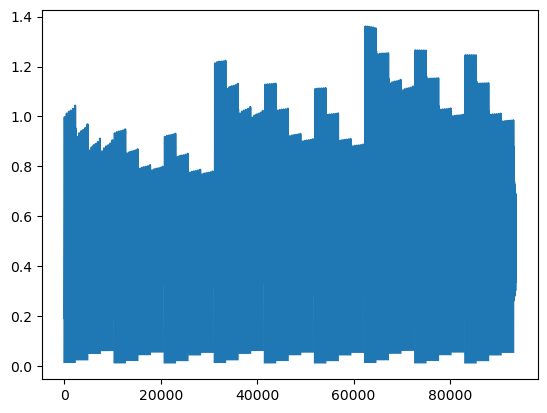

In [52]:
plt.plot(dataset[5,:])